***
*Project:* [Artificial Neuroscience: metrology and engineering for Deep Learning using Linear Algebra](https://www.seresearch.qmul.ac.uk/cmai/people/msandler/#grants)

*Author:* Jingwei Liu, Postdoctoral Research Associate, School of EECS, Queen Mary University of London

[[Centre for Digital Music (C4DM)](https://www.c4dm.eecs.qmul.ac.uk/people/) & [Centre for Fundamentals of AI and Computational Theory](https://www.seresearch.qmul.ac.uk/cfcs/people/jiliu/)]
***

# <span style="background-color:darkorange; color:white; padding:2px 6px">Document 1</span> 

# Low Rank Structure on Linear Weights

*Updated:* March 23, 2026


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Audio
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from typing import Dict, List, Union, Literal, Tuple, Optional, Any
import warnings

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from scipy.linalg import subspace_angles
import seaborn as sns
from dataclasses import dataclass

torch.cuda.is_available()

True

In [15]:
from utils0_loss import plot_training_curves, plot_training_curves_dual_round
from utils1_weights import extract_2d_weights_from_state_dict, classify_convtasnet_weights
from utils2_svd import compute_svd, compute_effective_rank
from utils4_analysis import visualize_singular_values_subplots, factorize_linear_weights, build_factored_state_dict, load_state_dict_with_resize,sync_factored_ranks_full
from utils_Conv_Tas_Net import ConvTasNet, PairedAudioDataset

## 1. 🎧 Conv-Tas Net for Audio Source Separation

---

### 🎯 1️⃣ The Goal of Source Separation

In the **source separation** task, we are given a **mixture waveform** containing multiple overlapping sources, such as two people speaking at the same time:

$$
x(t) = \sum_{i=1}^{C} s_i(t)
$$

where $C$ is the number of sources and $s_i(t)$ denotes the waveform of the $i$-th source. The goal is to recover each individual source signal $s_i(t)$ from only the observed mixture $x(t)$.

---

### 🧠 2️⃣ Conv-Tas Net: A Time-Domain Separation Model

To solve this problem, we train **Conv-Tas Net**, a neural network that performs separation **directly in the time domain**, without relying on a hand-crafted time-frequency transform. Instead, the model learns its own representation of the input waveform and predicts masks that isolate the latent components associated with each source.

#### Step 1: Encode the Mixture

The input waveform is first mapped into a learned latent representation:

$$
W = \mathrm{Encoder}(x)
$$

where $W \in \mathbb{R}^{N \times T}$ denotes the encoded mixture representation.

#### Step 2: Estimate Separation Masks

The separation network predicts one mask for each source:

$$
M_i = f_\theta(W), \quad M_i \in [0,1]^{N \times T}
$$

Each mask indicates which latent components of the mixture belong to source $i$.

#### Step 3: Apply the Masks

The latent representation for each source is obtained by masking the encoded mixture:

$$
D_i = M_i \odot W
$$

where $\odot$ denotes elementwise multiplication.

#### Step 4: Decode the Sources

Each masked latent representation is then converted back into a waveform:

$$
\hat{s}_i(t) = \mathrm{Decoder}(D_i)
$$

Thus, the model reconstructs an estimate $\hat{s}_i(t)$ for each separated source.

<div align="center">
    <img src="Conv-TasNet.jpg" width="1000">
    <p><b>Figure 1:</b> Conv-TasNet block diagram and system flow for time-domain source separation.</p>
</div>

Loading TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading best_val_loss from checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)


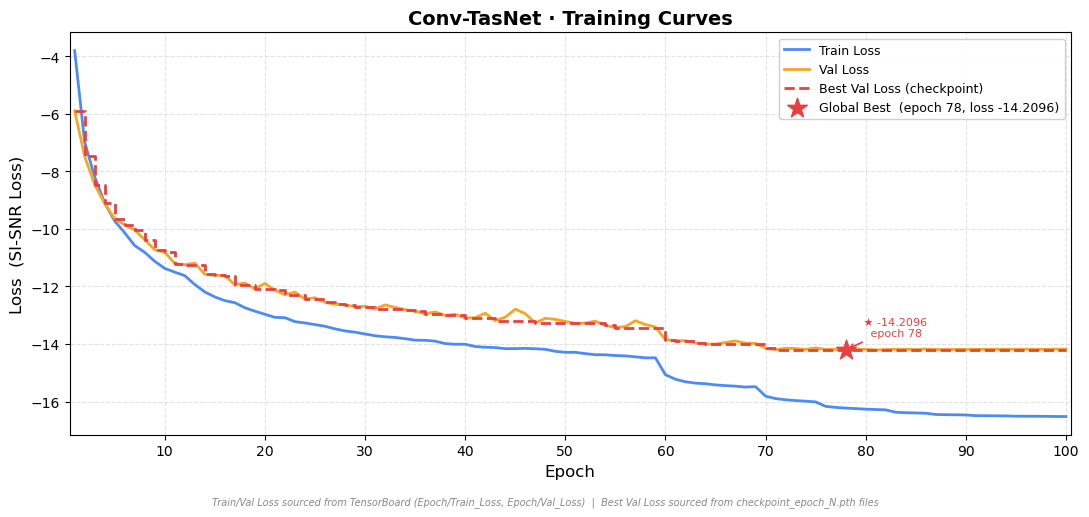

In [16]:
fig = plot_training_curves(
    log_dir        = 'HPC_Trained/Task1/logs',           # your SummaryWriter log_dir
    checkpoint_dir = 'HPC_Trained/Task1/checkpoints',    # your checkpoint_dir
    # save_path      = 'training_curves.png',
    figsize        = (11, 5),
    dpi            = 150,
    smooth_window  = 1,                  # set > 1 (e.g. 5) to smooth noisy curves
)
plt.show()

## 2. Inference

In [17]:
config = {
    # Model parameters
    'num_sources': 2,
    'encoder_dim': 512,
    'feature_dim': 128,
    'sample_rate': 8000,
    'window_ms': 2,
    'num_layers': 8,
    'num_stacks': 3,
    'kernel_size': 3,
    'causal': False,
    'use_skip': True,
    
    # Training parameters
    'batch_size': 6,
    'num_epochs': 100,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    
    # System parameters
    'device': 'cuda',
    'num_workers': 4,
    'checkpoint_dir': './checkpoints',
    'log_dir': './logs',
}

model = ConvTasNet(
    num_sources=config['num_sources'],
    encoder_dim=config['encoder_dim'],
    feature_dim=config['feature_dim'],
    sample_rate=config['sample_rate'],
    window_ms=config['window_ms'],
    num_layers=config['num_layers'],
    num_stacks=config['num_stacks'],
    kernel_size=config['kernel_size'],
    causal=config['causal'],
    use_skip=config['use_skip']
)

In [18]:
checkpoint = torch.load('HPC_Trained/Task1/checkpoints/best_model.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
mixed_signal, _ = librosa.load('D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix\\test-clean\mix_clean\\61_4992_264.wav', sr=config['sample_rate']) # test
Audio(mixed_signal, rate=config['sample_rate'])

In [20]:
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    separated_signal = model(torch.FloatTensor(mixed_signal).unsqueeze(0))
separated_signal.shape

torch.Size([1, 2, 71720])

In [21]:
Audio(separated_signal[:,0,:].squeeze(), rate=config['sample_rate'])

In [22]:
Audio(separated_signal[:,1,:].squeeze(), rate=config['sample_rate'])

## 3. Weight Singular Value Analysis

In [3]:
# Load checkpoint with the best valuation loss
checkpoint = torch.load('HPC_Trained/Task1/checkpoints/best_model.pth', map_location='cpu')
state_dict = checkpoint['model_state_dict']


In [4]:
# Extract all linear weights (pointwise convolution weights) from the Conv-Tas Net
weights_2d = extract_2d_weights_from_state_dict(state_dict)
_, linear_weights = classify_convtasnet_weights(weights_2d)
len(linear_weights)

74

### 🔍 Singular Value Decomposition (SVD) of a Weight Matrix

For a weight matrix $W \in \mathbb{R}^{m \times n}$, the **singular value decomposition (SVD)** writes $W$ as

$$
W = U \Sigma V^T
$$

where:

- $U \in \mathbb{R}^{m \times m}$ contains the **left singular vectors**
- $\Sigma \in \mathbb{R}^{m \times n}$ contains the **singular values**
- $V \in \mathbb{R}^{n \times n}$ contains the **right singular vectors**

---

#### 1️⃣ Expanded Matrix Form

The decomposition can be visualized as

$$
W_{m \times n}
=
\underbrace{
\begin{bmatrix}
\,|\, & \,|\, &        & \,|\, \\
u_1 & u_2 & \cdots & u_m \\
\,|\, & \,|\, &        & \,|\, 
\end{bmatrix}
}_{U \in \mathbb{R}^{m \times m}}
\;
\underbrace{
\begin{bmatrix}
\sigma_1 & 0 & 0 & \cdots & 0 \\
0 & \sigma_2 & 0 & \cdots & 0 \\
0 & 0 & \sigma_3 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & \sigma_r \\
0 & 0 & 0 & \cdots & 0 \\
\vdots & \vdots & \vdots &        & \vdots \\
0 & 0 & 0 & \cdots & 0
\end{bmatrix}
}_{\Sigma \in \mathbb{R}^{m \times n}}
\;
\underbrace{
\begin{bmatrix}
- v_1^T - \\
- v_2^T - \\
\vdots \\
- v_n^T -
\end{bmatrix}
}_{V^T \in \mathbb{R}^{n \times n}}
$$

Here:

- each $u_i \in \mathbb{R}^m$ is a **left singular vector**
- each $v_i \in \mathbb{R}^n$ is a **right singular vector**
- $\sigma_i$ measures the importance of the corresponding direction, $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$
- $r = \mathrm{rank}(W)$ is the number of nonzero singular values

---

#### 2️⃣ Sum of Rank-1 Components

SVD can also be written as a sum of simple outer products:

$$
W = \sum_{i=1}^{r} \sigma_i u_i v_i^T
$$

That is,

$$
W
=
\sigma_1 u_1 v_1^T
+ \sigma_2 u_2 v_2^T
+ \cdots
+ \sigma_r u_r v_r^T
$$

Each term $\sigma_i u_i v_i^T$ is a **rank-1 matrix**, so SVD expresses $W$ as a sum of weighted rank-1 directions.

---

#### 3️⃣ Why This Is Useful for Weight Analysis

If many singular values are very small, then those directions contribute little to the full matrix. In that case, we can approximate $W$ using only the top $k$ singular values:

$$
W \approx U_k \Sigma_k V_k^T
$$

where $k < r$. This gives a **low-rank approximation** that preserves the most important structure of the weight while reducing the number of effective parameters.

### Effective Rank

In SVD, **effective rank** means “how many singular directions *actually matter*,” even when the true algebraic rank is large (or full). It is a **real-valued** notion of dimensionality determined by how the singular values are distributed.

$$
\text{erank}(W) = \exp\left( -\sum_{i=1}^{r} p_i \log p_i \right)
$$

where the normalized singular value distribution is:

$$
p_i = \frac{\sigma_i}{\sum_{j=1}^{r} \sigma_j}
$$

In [33]:
# visualize_singular_values_subplots(linear_weights, log_scale=False, figsize_per_subplot=(5, 3.5))

## 4. Truncate Weights based on the Effective Ranks

#### What effective rank reveals (intuition → math)

- Intrinsic dimension / degrees of freedom: If $\operatorname{erank}(A)\approx k$, then $A$ behaves like it has about $k$ meaningful singular directions: many tasks (compression, denoising, regression conditioning) behave as if dimension were $k$, not $n$.

- How quickly low-rank approximations will work: Best rank-(k) approximation error is controlled by the tail singular values:
$$
A_k = \sum_{i=1}^k \sigma_i u_i v_i^\top,\qquad
||A-A_k||_F^2 = \sum_{i>k}\sigma_i^2,\quad
||A-A_k||_2 = \sigma_{k+1}.
$$
Effective rank summarizes *how concentrated* ${\sigma_i}$ are, which correlates strongly with how small those tails get for modest $k$.

In [ ]:
factored, num_orig_params, num_fact_params = factorize_linear_weights(linear_weights)

separator.bottleneck.weight                              shape ( 128, 512)  k=  34  
separator.conv_layers.0.conv_expand.weight               shape ( 512, 128)  k=  37  
separator.conv_layers.0.conv_residual.weight             shape ( 128, 512)  k= 100  
separator.conv_layers.0.conv_skip.weight                 shape ( 128, 512)  k=  85  
separator.conv_layers.1.conv_expand.weight               shape ( 512, 128)  k=  90  
separator.conv_layers.1.conv_residual.weight             shape ( 128, 512)  k= 111  
separator.conv_layers.1.conv_skip.weight                 shape ( 128, 512)  k= 100  
separator.conv_layers.2.conv_expand.weight               shape ( 512, 128)  k= 100  
separator.conv_layers.2.conv_residual.weight             shape ( 128, 512)  k= 109  
separator.conv_layers.2.conv_skip.weight                 shape ( 128, 512)  k= 103  
separator.conv_layers.3.conv_expand.weight               shape ( 512, 128)  k= 107  
separator.conv_layers.3.conv_residual.weight             shape ( 

### ✂️ Low-Rank Approximation via Truncated SVD

###  Full SVD

$$
W
=
\underbrace{
\begin{bmatrix}
| & | &        & | \\
u_1 & u_2 & \cdots & u_m \\
| & | &        & |
\end{bmatrix}
}_{U}
\underbrace{
\begin{bmatrix}
\sigma_1 & 0 & 0 & \cdots & 0 \\
0 & \sigma_2 & 0 & \cdots & 0 \\
0 & 0 & \sigma_3 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & \sigma_r \\
0 & 0 & 0 & \cdots & 0 \\
\vdots & \vdots & \vdots &        & \vdots \\
0 & 0 & 0 & \cdots & 0
\end{bmatrix}
}_{\Sigma}
\underbrace{
\begin{bmatrix}
- v_1^T - \\
- v_2^T - \\
\vdots \\
- v_n^T -
\end{bmatrix}
}_{V^T}
$$

---

### Truncate to Rank $k$

$$
W_k
=
\underbrace{
\begin{bmatrix}
| & | &        & | \\
u_1 & u_2 & \cdots & u_k \\
| & | &        & |
\end{bmatrix}
}_{U_k}
\underbrace{
\begin{bmatrix}
\sigma_1 & 0 & \cdots & 0 \\
0 & \sigma_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_k
\end{bmatrix}
}_{\Sigma_k}
\underbrace{
\begin{bmatrix}
- v_1^T - \\
- v_2^T - \\
\vdots \\
- v_k^T -
\end{bmatrix}
}_{V_k^T}
$$

---

### Parameter Reduction

A full matrix $W \in \mathbb{R}^{m \times n}$ has

$$
mn
$$

parameters.

The rank-$k$ factorization $W_k = AB$ uses

$$
mk + kn = k(m+n)
$$

parameters.

So the low-rank approximation reduces parameters whenever

$$
k(m+n) < mn
$$

which is typically true when $k \ll \min(m,n)$.

In [6]:
num_reduced_params = num_orig_params - num_fact_params
print(num_reduced_params, 'parameters reduced!')

473600 parameters reduced!


### 🔧 Balanced Factorization of Weight Matrix as $W=AB$

After computing the truncated SVD of a weight matrix $W \in \mathbb{R}^{m \times n}$ at rank $k$,

$$
W_k = U_k \Sigma_k V_k^T
$$

we re-parameterize the truncated weight as a product of two smaller matrices:

$$
W_k = AB
$$

where

$$
A = U_k \Sigma_k^{1/2} \in \mathbb{R}^{m \times k},
\qquad
B = \Sigma_k^{1/2} V_k^T \in \mathbb{R}^{k \times n}
$$

so that

$$
AB
=
U_k \Sigma_k^{1/2}\Sigma_k^{1/2}V_k^T
=
U_k \Sigma_k V_k^T
=
W_k
$$

This is exactly the low-rank form used to replace a large dense weight matrix by two smaller matrices.

In [7]:
# Build the new state_dict
factored_sd = build_factored_state_dict(state_dict, factored, factor_type='sqrt_svd')

## 5. Inspect Effect of Truncation on Model Performance

We replace the original linear weights in the Conv-Tas net by their truncated low-rank surrogates, and inspect how weight shrinkage affects the model performance.

### Illustration

$$
\text{Original layer:} \qquad y = Wx
$$

$$
\text{Compressed layer:} \qquad y \approx W_k x = ABx
$$

So the computation changes from one large dense mapping

$$
x \xrightarrow{W} y
$$

to a two-step low-rank mapping

$$
x \xrightarrow{B} \mathbb{R}^k \xrightarrow{A} y
$$

This introduces a narrow bottleneck of dimension $k$, forcing the model to use a more compact internal representation.

---

### Why This Experiment Matters

By substituting truncated low-rank weights into Conv-TasNet and evaluating the resulting model, we can directly observe how **weight shrinkage** affects separation quality.

- If performance drops only slightly, the layer contains substantial redundancy.
- If performance is preserved after compression, the model can be made much smaller without sacrificing effectiveness.
- If fine-tuning recovers or even improves performance, this suggests that the low-rank structure is not merely a compression trick, but a useful inductive bias.

In this way, the experiment serves as a controlled test of whether the learned linear weights in Conv-TasNet are **over-parameterized** and how far they can be compressed before performance meaningfully degrades.

In [16]:
from utils_Factored_Conv_Tas import ConvTasNet as Factored_ConvTasNet, Trainer

In [ ]:
config = {
    # Model parameters
    'num_sources': 2,
    'encoder_dim': 512,
    'feature_dim': 128,
    'sample_rate': 8000,
    'window_ms': 2,
    'num_layers': 8,
    'num_stacks': 3,
    'kernel_size': 3,
    'causal': False,
    'use_skip': True,
    'rank_factor': 4,
    
    # Training parameters
    'batch_size': 6,
    'num_epochs': 100,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    
    # System parameters
    'device': 'cuda',
    'num_workers': 0,
    'checkpoint_dir': './checkpoints',
    'log_dir': './logs',
}

model = Factored_ConvTasNet(
    num_sources=config['num_sources'],
    encoder_dim=config['encoder_dim'],
    feature_dim=config['feature_dim'],
    sample_rate=config['sample_rate'],
    window_ms=config['window_ms'],
    num_layers=config['num_layers'],
    num_stacks=config['num_stacks'],
    kernel_size=config['kernel_size'],
    causal=config['causal'],
    use_skip=config['use_skip'],
    rank_factor=config['rank_factor']
).to(config['device'])

In [14]:
matched, resized, skipped = load_state_dict_with_resize(
    model      = model,
    state_dict = factored_sd,
    verbose    = False,
)
sync_factored_ranks_full(model);

In [17]:
# For training
# Load mixed and source audio
mixed_dir_train = "D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix_4s\\train-clean-100_4s\mix_clean"
source_dirs_train = ["D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix_4s\\train-clean-100_4s\s1", \
                    "D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix_4s\\train-clean-100_4s\s2"]  # List of source directories
train__dataset = PairedAudioDataset(
    mixed_dir=mixed_dir_train,
    source_dirs=source_dirs_train,
    sample_rate=config['sample_rate'],
    expected_duration=4.0
)

train_loader = DataLoader(
        train__dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=config['num_workers'],
        pin_memory=True
    )

# For validation
# Load mixed and source audio
mixed_dir_val = 'D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix_4s\dev_clean_4s\mix_clean'
source_dirs_val = ['D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix_4s\dev_clean_4s\s1', \
                'D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix_4s\dev_clean_4s\s2']  # List of source directories
val_dataset = PairedAudioDataset(
    mixed_dir=mixed_dir_val,
    source_dirs=source_dirs_val,
    sample_rate=config['sample_rate'],
    expected_duration=4.0
)
val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,  # Validation should not shuffle
        num_workers=config['num_workers'],
        pin_memory=True
    )

📁 Found 33640 matching audio files
📁 Found 3812 matching audio files


In [20]:
# Valuation Loss
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=torch.optim.Adam(model.parameters())
)
trainer.validate()

-14.003267823525196

In [24]:
checkpoint['best_val_loss']

-14.209594413169524

In [25]:
# Training Loss
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=train_loader,
    optimizer=torch.optim.Adam(model.parameters())
)
trainer.validate()

-15.920419854064964

- Original Training Loss: -16.24

**The performance drops only slightly (nearly the same)**

In [29]:
model.to('cpu').eval()  # Set model to evaluation mode
with torch.no_grad():
    separated_signal = model(torch.FloatTensor(mixed_signal).unsqueeze(0))
separated_signal.shape

torch.Size([1, 2, 71720])

In [30]:
Audio(separated_signal[:,0,:].squeeze(), rate=config['sample_rate'])

In [31]:
Audio(separated_signal[:,1,:].squeeze(), rate=config['sample_rate'])

## 6. Fine-Tune the Factored Low-Rank Conv-Tas Net

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 78  (loss -14.2096)
Round 2 epoch offset = 78  (R2 local ep 1 → global ep 79)

R2 Train Loss anchor injected at local ep 0 (global ep 78): -15.9204
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global ep 7

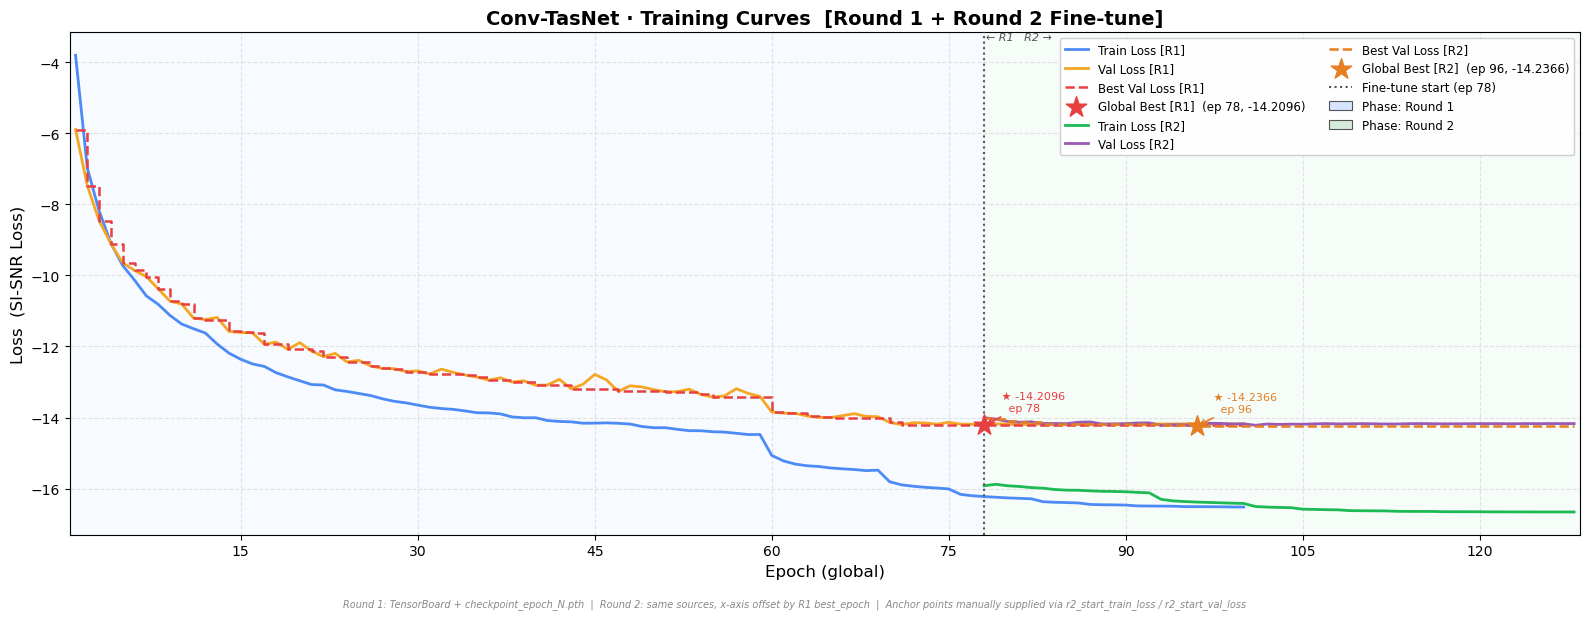

In [32]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task1/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task1/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task1_tune_free/logs',
    r2_checkpoint_dir = "HPC_Trained/Task1_tune_free/checkpoints",

    r2_start_train_loss = -15.920419854064964,   
    r2_start_val_loss   = -14.003267823525196,

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()

- The fine tuning reduced the validation loss to $-14.23$ in a few epochs, which is even better than the full original model (validation loss $-14.20$)!

# Dual-Phase Adaptive Low-Rank (DALR)

The fine-tuning stage gives an even more encouraging result: after only a few epochs, the validation loss improves to $-14.23$, slightly better than the original full model at $-14.20$. This suggests that rank reduction is not merely a way to save parameters or compress model size. Instead, it may reveal a **better structural form** of the weight—one that removes redundancy, keeps the most useful directions, and leads to a more efficient representation for the task. In other words, low-rank structure may act not only as a compression tool, but also as a form of **inductive bias** that can improve optimization and generalization.

This observation naturally leads to a broader question:

> Can we train a compact and efficient model whose rank $k$ is optimized for the task itself?

More specifically, rather than fixing the rank by hand or compressing only after training, we would like to **search for the most effective rank**: one that is small enough to reduce redundancy and model size, yet expressive enough to match—or even outperform—the original full-rank weight matrices. Motivated by this idea, we design several mechanisms for **adaptive low-rank training**, where the model can automatically adjust its rank during learning.

## Training Procedure

- **Every step:**  
  Standard gradient update on $A, B$

- **Every $T$ steps:**
  - **Re-balance $A, B$** — Re-express A, B in the SVD basis and restore the $\Sigma^{1/2}$ split
  - **SVT prune** — zero singular values $\sigma_i < \tau_{\text{prune}}$
  - **Residual probe** — grow rank if $\|\Delta W\|_F > \tau_{\text{grow}}$

- **On convergence:**  
  Freeze rank and export merged weight $W = A B$

---

### 1. Growth Criterion

Growth is determined by the **gradient residual outside the current row and column spaces**:

$$
\Delta W = \underbrace{(I - P_U)}_{\text{left residual}} \; \nabla_W \mathcal{L} \; \underbrace{(I - P_V)}_{\text{right residual}}
$$
​​where $P_U = Q_U Q_U^\top$​ and $P_V = Q_V Q_V^\top$​ are orthogonal projectors onto the column and row spaces of $W$, respectively. If $\|\Delta W\|_F > \tau_{\text{grow}}$, the **top singular direction of $\Delta W$** is appended to the factorization.


### 2. Pruning Criterion

Pruning uses **soft thresholding on the singular values** of the reconstructed matrix $W_k = AB$:

$$
\hat{\sigma}_i \leftarrow \max(\hat{\sigma}_i - \tau_{\text{prune}},\ 0)
$$

Directions where $\hat{\sigma}_i = 0$ are removed, and the corresponding **columns of $A$** and **rows of $B$** are physically deleted.

### 3. Rank Schedule Intuition

- **Early training:** higher rank helps explore the loss landscape.  
- **Late training:** lower rank improves compression and stability.

Therefore the thresholds are **annealed over time**.

### Pruning Threshold (increases over time)

$$
\tau_{\text{prune}}(t)
=
\tau_0
\left(
1 - e^{-t / T_{\text{anneal}}}
\right)
$$

Pruning becomes **more aggressive** as training progresses.

### Growth Threshold (decreases over time)

$$
\tau_{\text{grow}}(t)
=
\tau_0^{\text{grow}}
\cdot
e^{-t / T_{\text{anneal}}}
$$

Rank growth becomes **harder over time**, stabilizing the final model.